In [234]:
from src.layers.transformer.ATAT import LightCurveTransformer
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY,ZTF_TAXONOMY
import pandas as pd

In [235]:
colors = [
    '#ffacfa',# agn
    '#D747CF', #qso 1
    "#189a95", # EA 2

    "#bb3e00", #yso 3
    '#70df00',  # snia 4
    "#FE0912", # cvnova 5
    
    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
    "#cd0066",#'#96034A', #blacar 8
    
    '#2F8B04', # snii 9 
    '#7a71f8', # ebew 10
    "#822ffd", #lpv 11
    
    '#50aceb', # cep 12
    '#00e3ff', # rrlab 13
    '#1FA9FF', # periodic other 14
    '#00e3ff ', #dsct 15
    "#458a00", # snibc 16
    "#1E5A2E", # slsn 17
    "#ff8000", # tde 18

    '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
    "#FFFFFF", # microlensing 21
    ]

colors_hier = [
    #,'#554FCF
    #'#FBAC23', #agn 0
    '#fd31ee',# agn
    '#fd31ee', #qso 1
    '#00e3ff', # EA 2

    '#fd31ee', #yso 3
    '#1bda00',  # snia 4
    '#fd31ee', # cvnova 5
    '#00e3ff',# 6 rrlc  tt
    '#00e3ff',  # 7 rscvn
    '#fd31ee',#'#96034A', #blacar 8
    '#1bda00', # snii 9 
    '#00e3ff', # ebew 10
    '#00e3ff', #lpv 11
    
    '#00e3ff', # cep 12
    '#00e3ff', # rrlab 13
    '#00e3ff', # periodic other 14
    '#60fff3 ', #dsct 15
    '#1bda00', # snibc 16
    '#1bda00', # slsn 17
    '#1bda00', # tde 18
    '#1bda00', # sniib 19
    '#1bda00', # sniin 20
    '#1bda00', # microlensing 21
    ]

In [236]:
PATH = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/200/LC/test_v3/'
FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'
DEVICE = 'cuda:0'
TAXONOMY = ZTF_TAXONOMY

In [237]:
from src.exploringtools.ExplorePretraining import ExplorePretraining
from src.exploringtools.InitDataloader import InitDataLoader
test = ExplorePretraining(path_to_config_yaml=PATH,
                    model= LightCurveTransformer, 
                    arg_key='lc')
od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='pretrain_ckpt')
test.load_backbone_weights(od)
dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)

Found checkpoint 2337.ckpt
Loaded backbone weights
not using sampler


/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_cl

In [238]:
X_val, y_val =test.predict(dl.validation_dataset, DEVICE)

device set to cuda:0


100%|██████████| 382/382 [00:07<00:00, 49.35it/s]


In [239]:
target = y_val
from sklearn.discriminant_analysis import StandardScaler
import umap
import umap.plot
#from bokeh.resources import INLINE
#import bokeh.io
scaler = StandardScaler()
#bokeh.io.output_notebook(INLINE)
umap_args = {'min_dist':0.99}
umap_obj = umap.UMAP(**umap_args)
mapper = umap_obj.fit(scaler.fit_transform(X_val))
hover_data = pd.DataFrame({'index':range(len(X_val)),
                            'label':y_val, 
                            })

hover_data['class'] = hover_data.label.map({value:key for key,value in TAXONOMY().items()})

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [240]:
umap.plot.output_notebook()
p = umap.plot.interactive(mapper, 
    labels=target,
    hover_data=hover_data,
    point_size=6,
    tools=["pan","wheel_zoom",
    "box_zoom","save",
    "reset","box_select"],
    width=1920,
    height=1080,
    #theme = 'fire',
    #color_key = colors_hier,
    color_key = colors,
    background = 'black', #midnightblue',
    alpha = 1)
umap.plot.show(p)

Loading BokehJS ...

In [241]:
#dl.set_sampler(True)
X_train, y_train =test.predict(dl.train_dataset, DEVICE)

device set to cuda:0


  0%|          | 0/1525 [00:00<?, ?it/s]

100%|██████████| 1525/1525 [00:29<00:00, 51.34it/s]


In [242]:
class_sampler_count  = [1783,1804,1785,1526,1566,1008,1855,1440,872,891,1858,1860,1814,1876,763,973,278,121,56,70,172,17]

weights_dict = {float(i): 1/class_sampler_count[i] for i in range(len(class_sampler_count))}

In [243]:
from sklearn.metrics import classification_report
train_preds, val_preds = test.compute_logistic_regressor(X_train, y_train, X_val, y_val, ZTF_TAXONOMY,weights = weights_dict)

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
0.1631,0.1818,0.2008,0.2121,0.2094,0.2283,0.2407

(0.1631, 0.1818, 0.2008, 0.2121, 0.2094, 0.2283)

                precision    recall  f1-score   support

           AGN     0.2768    0.0700    0.1117       443
           QSO     0.5341    0.7065    0.6083       477
            EA     0.4660    0.5677    0.5118       495
           YSO     0.2465    0.0829    0.1241       422
          SNIa     0.5702    0.3573    0.4393       375
       CV/Nova     0.4732    0.1956    0.2768       271
          RRLc     0.4279    0.5802    0.4925       455
         RSCVn     0.1250    0.0148    0.0265       338
        Blazar     0.1846    0.0571    0.0873       210
          SNII     0.4219    0.1311    0.2000       206
         EB/EW     0.4703    0.3664    0.4119       453
           LPV     0.4390    0.6987    0.5392       458
           CEP     0.3333    0.1626    0.2186       449
         RRLab     0.3929    0.6933    0.5016       450
Periodic-Other     0.1806    0.4040    0.2496       198
          DSCT     0.1667    0.1116    0.1337       242
         SNIbc     0.0870    0.1515    0.1105  

<Axes: title={'center': 'logit reg: validation | macro f1: 0.2407'}, xlabel='Predicted label', ylabel='True label'>

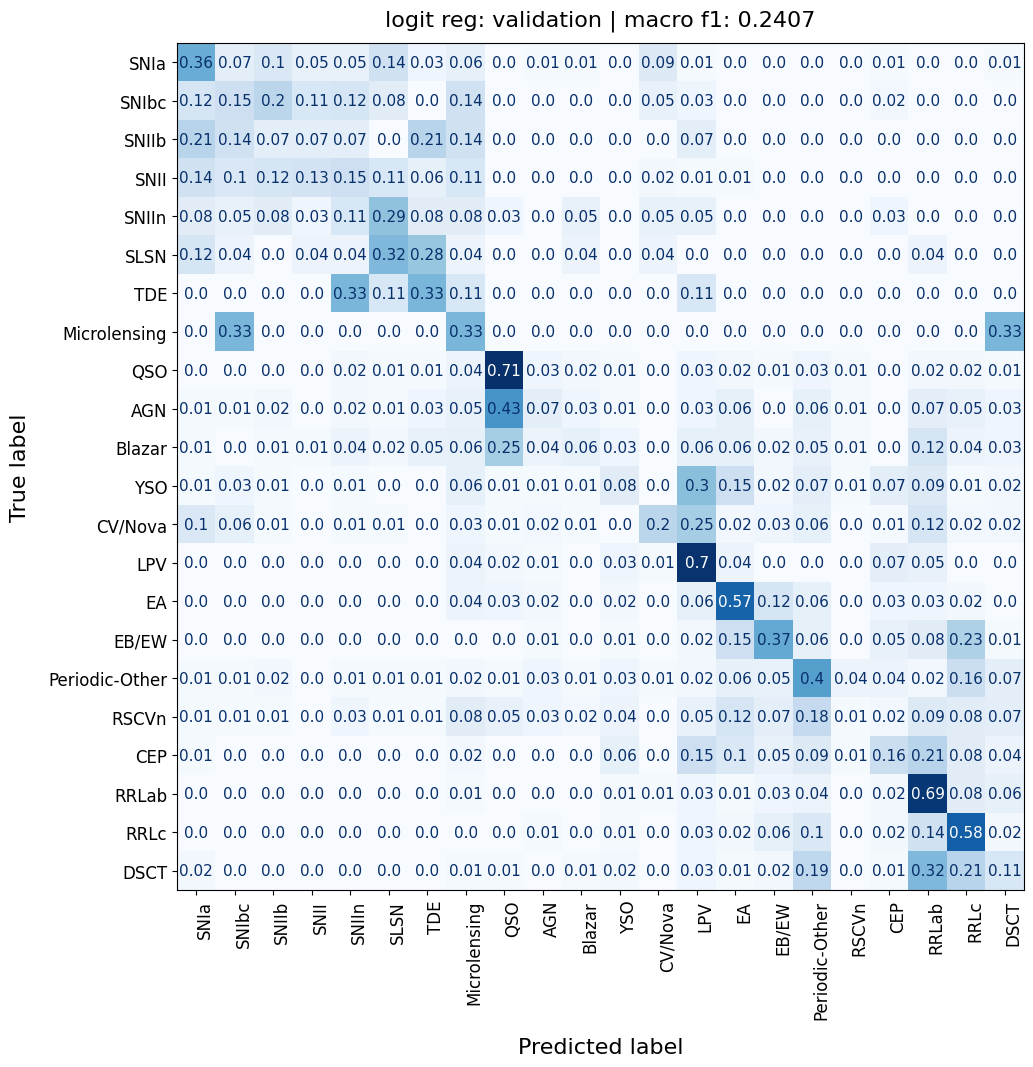

In [245]:
print(classification_report(y_val,val_preds, target_names=list(TAXONOMY().keys()),digits = 4))
test.get_confusion_matrix(val_preds, y_val, ZTF_TAXONOMY, dataset_type = 'validation')

                precision    recall  f1-score   support

           AGN     0.3106    0.3905    0.3460       443
           QSO     0.5677    0.5891    0.5782       477
            EA     0.6964    0.7091    0.7027       495
           YSO     0.3843    0.4052    0.3945       422
          SNIa     0.5558    0.8240    0.6638       375
       CV/Nova     0.5894    0.4502    0.5105       271
          RRLc     0.5102    0.6571    0.5744       455
         RSCVn     0.3082    0.3018    0.3049       338
        Blazar     0.3301    0.1619    0.2173       210
          SNII     0.4514    0.3835    0.4147       206
         EB/EW     0.5957    0.6181    0.6067       453
           LPV     0.6247    0.6725    0.6477       458
           CEP     0.4486    0.3697    0.4054       449
         RRLab     0.6120    0.6800    0.6442       450
Periodic-Other     0.1825    0.1263    0.1493       198
          DSCT     0.2143    0.1116    0.1467       242
         SNIbc     0.0833    0.0303    0.0444  

<Axes: title={'center': 'logit reg: validation | macro f1: 0.3373'}, xlabel='Predicted label', ylabel='True label'>

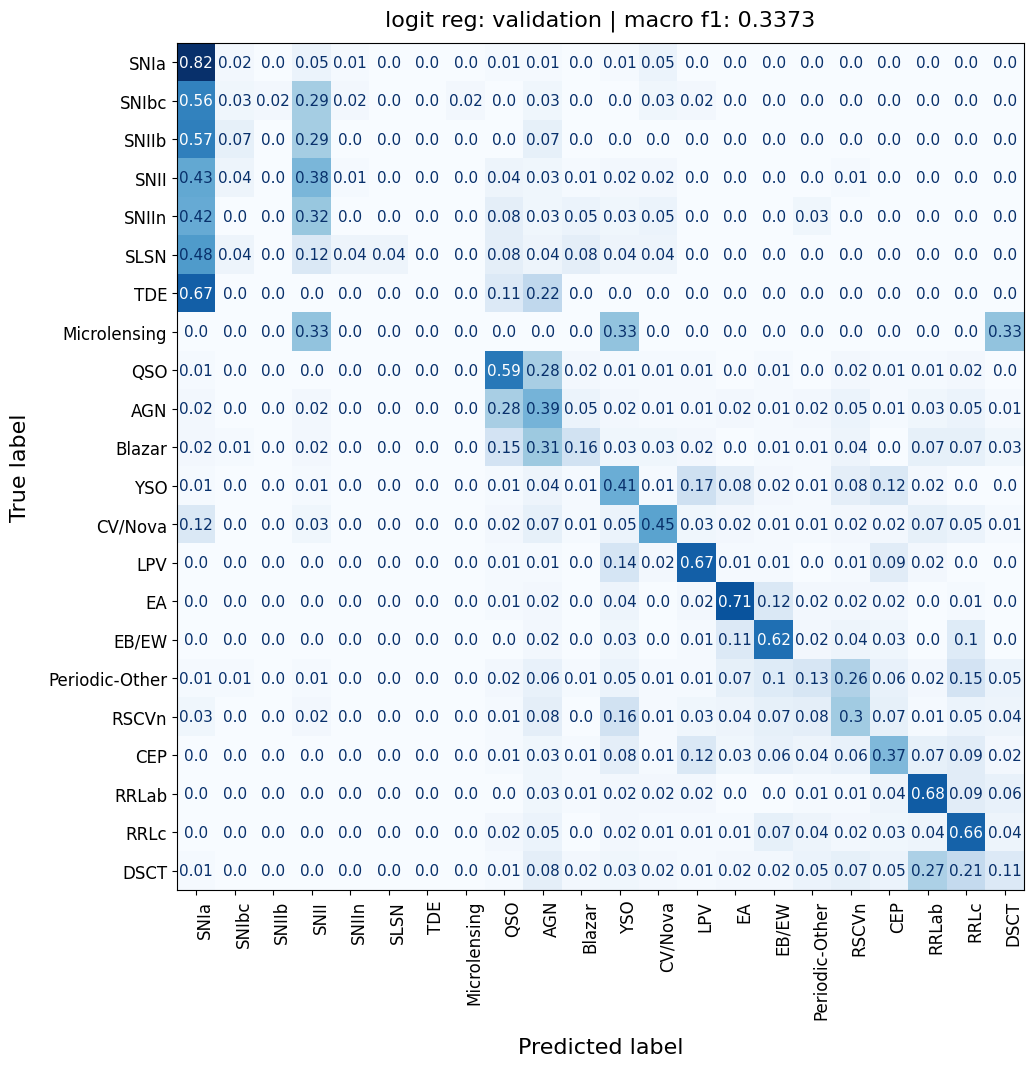

In [246]:
train_preds, val_preds = test.compute_knn(X_train, y_train, X_val, y_val, ZTF_TAXONOMY)
print(classification_report(y_val,val_preds, target_names=list(TAXONOMY().keys()),digits = 4))
test.get_confusion_matrix(val_preds, y_val, ZTF_TAXONOMY, dataset_type = 'validation')

In [247]:
#print(classification_report(y_train,train_preds, target_names=list(TAXONOMY().keys()),digits = 4))

In [248]:
asdf

NameError: name 'asdf' is not defined

In [ ]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

model1 = Pipeline([
            ('scaler', StandardScaler()),  # z = (x - mean) / std
            ('model', LogisticRegression(random_state=0, max_iter = 1000, multi_class = 'ovr', class_weight=weights_dict))
        ])
model2 =  Pipeline([
            ('scaler', StandardScaler()),  # z = (x - mean) / std
             ('model', KNeighborsClassifier(n_neighbors=3,weights='distance'))
        ])
model3 = RandomForestClassifier()

ensemble = VotingClassifier(estimators=[
    ('lr', model1), 
    ('rf', model3),
     ('model', model2)
], voting='soft')
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_val)

print(classification_report(y_val,y_pred, target_names=list(TAXONOMY().keys()),digits = 4))

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


KeyboardInterrupt: 